**Digit Classifer Using Support Vector Machine**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df= pd.read_csv('/content/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
df.shape

(42000, 785)

In [26]:
df['label'].value_counts()

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


In [27]:
label_val= np.where(df['label']== 5)
label_val= np.array(label_val[0])
label_val[0:5]

array([ 8, 19, 51, 62, 80])

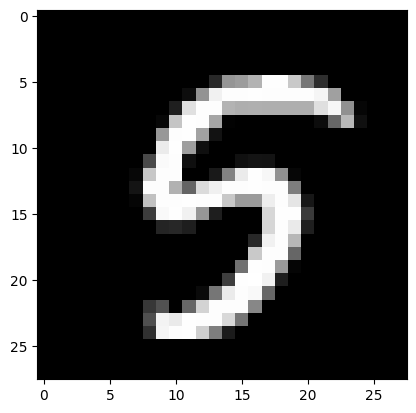

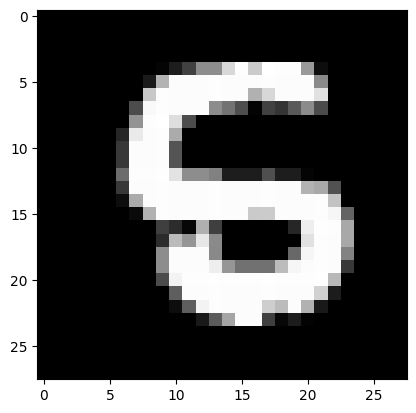

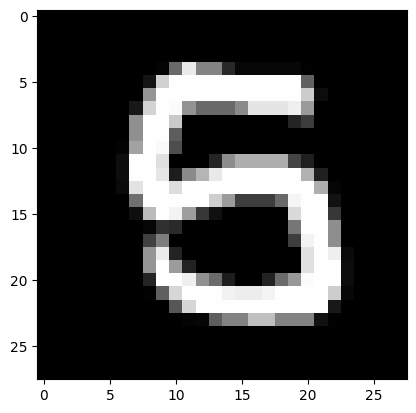

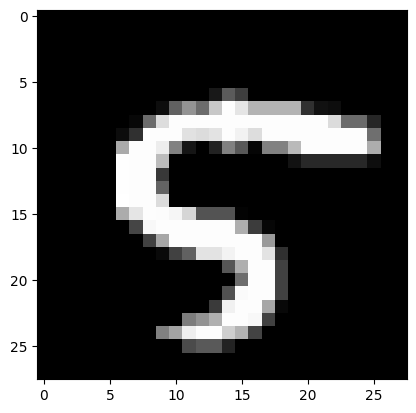

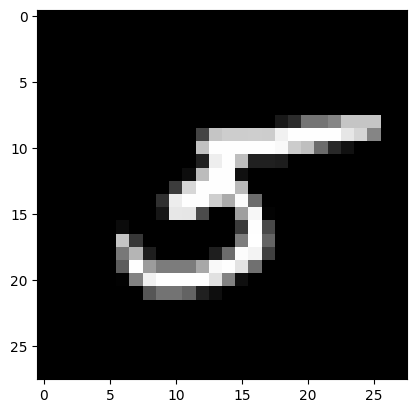

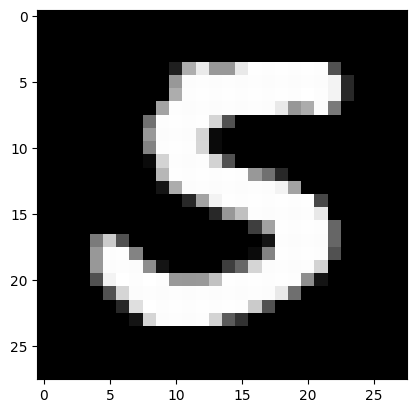

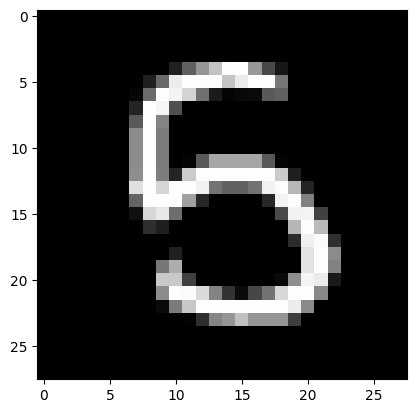

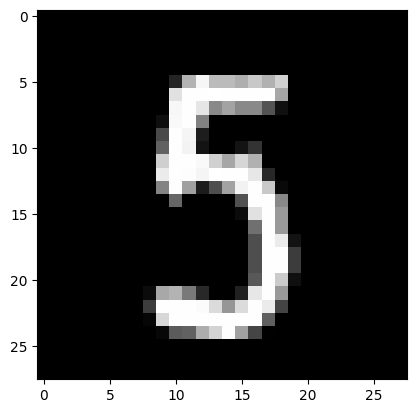

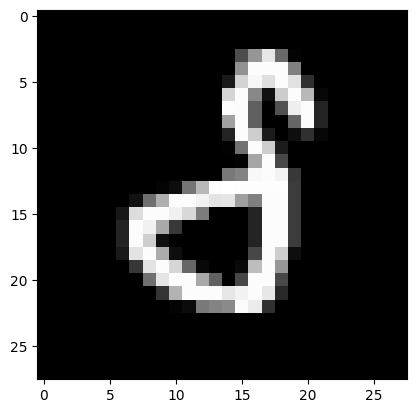

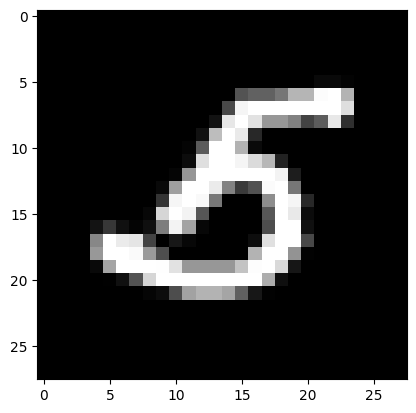

5


In [28]:
# plt.figure(figsize= (10,10))
for i in label_val[0:10]:
  img= df.iloc[i,1:]
  img= img.values.reshape(28,28)
  plt.imshow(img, cmap= 'gray')
  plt.show()
print(df.iloc[i,0])


In [29]:
X= df.drop('label', axis=1)
Y= df['label']

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(X, Y, test_size= 0.3, random_state= 100)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((29400, 784), (12600, 784), (29400,), (12600,))

In [32]:
from sklearn.svm import SVC
model= SVC(probability=True)
model.fit(x_train, y_train)

SVC(probability=True)

In [17]:
model.score(x_train, y_train), model.score(x_test, y_test)

(0.9883333333333333, 0.9738095238095238)

In [33]:
y_pred= model.predict(x_test)

In [ ]:
# y_pred1= model.predict_proba(x_test)

In [34]:
from sklearn.metrics import accuracy_score
acc= accuracy_score(y_test, y_pred)
acc

0.9738095238095238

In [35]:
from sklearn.metrics import classification_report
cr= classification_report(y_test, y_pred)
cr

'              precision    recall  f1-score   support\n\n           0       0.98      0.99      0.99      1242\n           1       0.99      0.99      0.99      1424\n           2       0.96      0.97      0.96      1199\n           3       0.98      0.97      0.97      1296\n           4       0.96      0.97      0.97      1204\n           5       0.97      0.97      0.97      1178\n           6       0.98      0.99      0.99      1250\n           7       0.97      0.97      0.97      1284\n           8       0.97      0.96      0.96      1236\n           9       0.96      0.96      0.96      1287\n\n    accuracy                           0.97     12600\n   macro avg       0.97      0.97      0.97     12600\nweighted avg       0.97      0.97      0.97     12600\n'

In [36]:
import joblib
joblib.dump(model, 'DC_SVM_model.joblib')

['DC_SVM_model.joblib']

In [21]:
import joblib
joblib.dump(model, 'DC_SVM_model.pkl')

['DC_SVM_model.pkl']

In [37]:
x_test.sample()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
2553,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
see= np.array(x_test.loc[2553])
see= see.reshape(28,28)
for i in range(len(see)):
  for j in range(len(see)):
    if see[i][j] != 0 and see[i][j] >=100:
      print(see[i][j], end=' ')
    elif see[i][j] != 0 and see[i][j] >=10:
      print(see[i][j], end=' ')
    elif see[i][j] != 0 and see[i][j] < 10:
      print('0', see[i][j], end=' ')
    else:
      print('   ', end=" ")
  print()
# see.shape

                                                                                                                
                                                                                                                
                                                                                                                
                                                                                                                
                                                                                                                
                                                                                                                
                                                                                                                
                                    0 7 117 141 204 228 141 141 141 141 141 141 13                             
                                70 187 252 252 253 252 252 252 253 252 252 252 207 56            

In [53]:
d= x_test.loc[2553]
list(d)
print(d)

pixel0      0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Name: 2553, Length: 784, dtype: int64


In [41]:
y_test.loc[2553]

np.int64(7)

In [50]:
a= model.predict_proba([d])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([[3.77991713e-03, 8.37298805e-05, 1.76691795e-03, 2.38437800e-02,
        4.13786665e-04, 2.02784530e-03, 2.54076255e-05, 9.94287639e+01,
        2.34331131e-03, 5.36951427e-01]])